# 📊 ANÁLISIS ESTADÍSTICO DE ACCIDENTES DE TRÁFICO 🚑🚦

## 🌍 INTRODUCCIÓN  
Los accidentes de tráfico representan una grave preocupación global en materia de salud pública, siendo una de las principales causas de mortalidad y lesiones severas que afectan a millones de personas anualmente. Ante esta problemática apremiante, el presente trabajo se embarca en un Análisis Exploratorio de Datos detallado del conjunto de datos "Traffic Accidents". Nuestro objetivo es ir más allá de las cifras superficiales, buscando identificar patrones significativos, descubrir factores de riesgo latentes y discernir tendencias clave que influyen en la ocurrencia y la gravedad de estos siniestros viales. Mediante una exploración visual y estadística exhaustiva de este dataset, aspiramos a transformar los datos brutos en información valiosa y actionable que impulse la toma de decisiones informadas, y que, en última instancia, contribuya directamente a la mejora sustancial de la seguridad vial en nuestras comunidades.

**📌 Importancia del estudio:**  
Este análisis proporciona información valiosa para:
- 🏛️ Diseño de políticas públicas efectivas  
- 🛡️ Implementación de medidas preventivas  
- 💔 Reducción de mortalidad vial  
- 🚨 Optimización de recursos de emergencia  

![Imagen ilustrativa de accidente de tráfico](https://drive.google.com/uc?export=view&id=1qj_xfmdTrY7ozloH6lBMR1pMKA6Y8bLJ)

## 📚 FUENTE DE DATOS
Los datos utilizados en este análisis fueron obtenidos del dataset público:  
🔗 [Traffic Accidents Dataset](https://www.kaggle.com/datasets/oktayrdeki/traffic-accidents/data) en [Kaggle](https://www.kaggle.com)

## 📋 VARIABLES DEL ESTUDIO  

### 🔠 VARIABLES CUALITATIVAS  
| Variable | Descripción | Ejemplo de valores |
|----------|-------------|--------------------|
| 🚦 `Dispositivo control` | Control de tráfico presente | Semáforo, señal stop |
| 🌧️ `Condición climática` | Clima durante el accidente | Lluvia, soleado |
| 💡 `Iluminación` | Condiciones de luz | Día, noche con luces |
| 📅 `Día de la semana` | Día de ocurrencia | Lunes, Domingo |
| 🏥 `Gravedad lesiones` | Severidad del accidente | Fatal, leve |

### 🔢 VARIABLES CUANTITATIVAS  
| Variable | Descripción | Rango típico |
|----------|-------------|-------------|
| 🚗 `Vehículos` | Nº de vehículos involucrados | 1-10 |
| 🤕 `Lesiones totales` | Personas lesionadas | 0-50 |
| ⚰️ `Lesiones fatales` | Lesiones mortales | 0-10 |
| ⏰ `Hora` | Hora del accidente (24h) | 0-23 |
| 🗓️ `Mes` | Mes de ocurrencia | 1-12 |

## 🎯 OBJETIVOS  

**🎯 Objetivo principal:**  
Identificar patrones, factores de riesgo y tendencias en accidentes de tráfico para mejorar la seguridad vial.  

## 👥 AUTORES  
Este análisis fue realizado por:  

| Nombre | Código |
|--------|--------|
| Harver Alejandro Sierra García | 2204124 |
| Javier Alejandro Silva Murillo | 2211860 |
| Nicolas Esteban Garcia Tamayo | 2211233 |

**🏫 Institución:** Universidad Industrial De Santander  

In [ ]:
#@title Carga el dataframe
# [Kaggle_traffic-accidents](https://www.kaggle.com/datasets/oktayrdeki/traffic-accidents/data)
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns


#from google.colab import drive
#drive.mount('/content/drive/')

df0 = pd.read_csv('https://drive.google.com/uc?id=1ZeiNMmjUTucHLJl0hFI-TbLUX5zpwMsU',encoding='latin-1')




# Seleccion y conversion de datos

# Seleccionamos datos representativos (Excluye crash_date como objeto por ser redundante)
df = df0[['num_units',
          'injuries_total',
          'injuries_fatal',
          'injuries_incapacitating',
          'injuries_non_incapacitating',
          'injuries_reported_not_evident',
          'injuries_no_indication',
          'crash_hour',
          'crash_day_of_week',
          'crash_month',
          'traffic_control_device',
          'weather_condition',
          'lighting_condition',
          'first_crash_type',
          'trafficway_type',
          'alignment',
          'roadway_surface_cond',
          'road_defect',
          'crash_type',
          'intersection_related_i',
          'damage',
          'prim_contributory_cause',
          'most_severe_injury']]

# Traducciones
df['traffic_control_device'] = df['traffic_control_device'].replace({
    'TRAFFIC SIGNAL': 'Semáforo',
    'STOP SIGN/FLASHER': 'Pare/Intermitente',
    'NO CONTROLS': 'Sin controles',
    'UNKNOWN': 'Desconocido',
    'OTHER': 'Otro',
    'YIELD': 'Ceda el paso',
    'PEDESTRIAN CROSSING SIGN': 'Paso peatonal',
    'OTHER REG. SIGN': 'Otra señal reglamentaria',
    'LANE USE MARKING': 'Marcado de carril',
    'FLASHING CONTROL SIGNAL': 'Señal intermitente',
    'POLICE/FLAGMAN': 'Agente de tránsito',
    'OTHER WARNING SIGN': 'Otra señal de advertencia',
    'RAILROAD CROSSING GATE': 'Barreras ferroviarias',
    'SCHOOL ZONE': 'Zona escolar',
    'OTHER RAILROAD CROSSING': 'Otro cruce ferroviario',
    'RR CROSSING SIGN': 'Señal cruce ferroviario',
    'DELINEATORS': 'Delineadores',
    'NO PASSING': 'Prohibido adelantar',
    'BICYCLE CROSSING SIGN': 'Señal de cruce ciclista'
})

df['weather_condition'] = df['weather_condition'].replace({
    'CLEAR': 'Despejado',
    'RAIN': 'Lluvia',
    'CLOUDY/OVERCAST': 'Nublado',
    'SNOW': 'Nieve',
    'UNKNOWN': 'Desconocido',
    'OTHER': 'Otro',
    'FREEZING RAIN/DRIZZLE': 'Llovizna helada',
    'FOG/SMOKE/HAZE': 'Niebla/Humo/Niebla ligera',
    'SLEET/HAIL': 'Aguanieve/Granizo',
    'BLOWING SNOW': 'Ventisca',
    'SEVERE CROSS WIND GATE': 'Viento cruzado severo',
    'BLOWING SAND, SOIL, DIRT': 'Tormenta de arena/polvo'
})

df['lighting_condition'] = df['lighting_condition'].replace({
    'DAYLIGHT': 'Luz del día',
    'DARKNESS, LIGHTED ROAD': 'Oscuridad, vía iluminada',
    'DARKNESS': 'Oscuridad',
    'DUSK': 'Anochecer',
    'DAWN': 'Amanecer',
    'UNKNOWN': 'Desconocido'
})




df['most_severe_injury'] = df['most_severe_injury'].replace({
    'NO INDICATION OF INJURY': 'Sin indicio de lesión',
    'NONINCAPACITATING INJURY': 'Lesión no incapacitante',
    'REPORTED, NOT EVIDENT': 'Reportada, no evidente',
    'INCAPACITATING INJURY': 'Lesión incapacitante',
    'FATAL': 'Mortal'
})

df['crash_day_of_week'] = df['crash_day_of_week'].replace({
    7: 'Domingo',
    1: 'Lunes',
    2: 'Martes',
    3: 'Miércoles',
    4: 'Jueves',
    5: 'Viernes',
    6: 'Sábado'
})


<ipython-input-2-2478c210584c>:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['traffic_control_device'] = df['traffic_control_device'].replace({
<ipython-input-2-2478c210584c>:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['weather_condition'] = df['weather_condition'].replace({
<ipython-input-2-2478c210584c>:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation

In [ ]:
#@title Seleccionar las columnas deseadas
columnas_a_mantener = [
    "traffic_control_device",
    "weather_condition",
    "lighting_condition",
    "crash_day_of_week",
    "num_units",
    "injuries_total",
    "injuries_fatal",
    "crash_hour",
    "crash_month",
    "most_severe_injury"
]

# Eliminar columnas que no están en la lista
columnas_a_eliminar = [col for col in df.columns if col not in columnas_a_mantener]
df = df.drop(columnas_a_eliminar, axis=1)

# Reemplazar valores vacíos y NaN
df.replace(['', ' ', 'NA', 'None'], np.nan, inplace=True)
df = df.dropna()

# Renombrar columnas
df.rename(columns={
    'traffic_control_device': 'DispositivoControlTrafico',
    'weather_condition': 'CondicionClimatica',
    'lighting_condition': 'CondicionIluminacion',
    'crash_day_of_week': 'DiaSemanaAccidente',
    'num_units': 'NumeroVehiculos',
    'injuries_total': 'LesionesTotales',
    'injuries_fatal': 'LesionesFatales',
    'crash_hour': 'HoraAccidente',
    'crash_month': 'MesAccidente',
    'most_severe_injury': 'GravedadLesiones'
}, inplace=True)

# Mostrar el DataFrame resultante
print(df.head())

   NumeroVehiculos  LesionesTotales  LesionesFatales  HoraAccidente  \
0                2              0.0              0.0             13   
1                2              0.0              0.0              0   
2                3              0.0              0.0             10   
3                2              5.0              0.0             19   
4                2              0.0              0.0             14   

  DiaSemanaAccidente  MesAccidente DispositivoControlTrafico  \
0            Domingo             7                  Semáforo   
1              Lunes             8                  Semáforo   
2            Viernes            12                  Semáforo   
3             Jueves             8                  Semáforo   
4            Domingo             8                  Semáforo   

  CondicionClimatica      CondicionIluminacion         GravedadLesiones  
0          Despejado               Luz del día    Sin indicio de lesión  
1          Despejado  Oscuridad, vía ilu

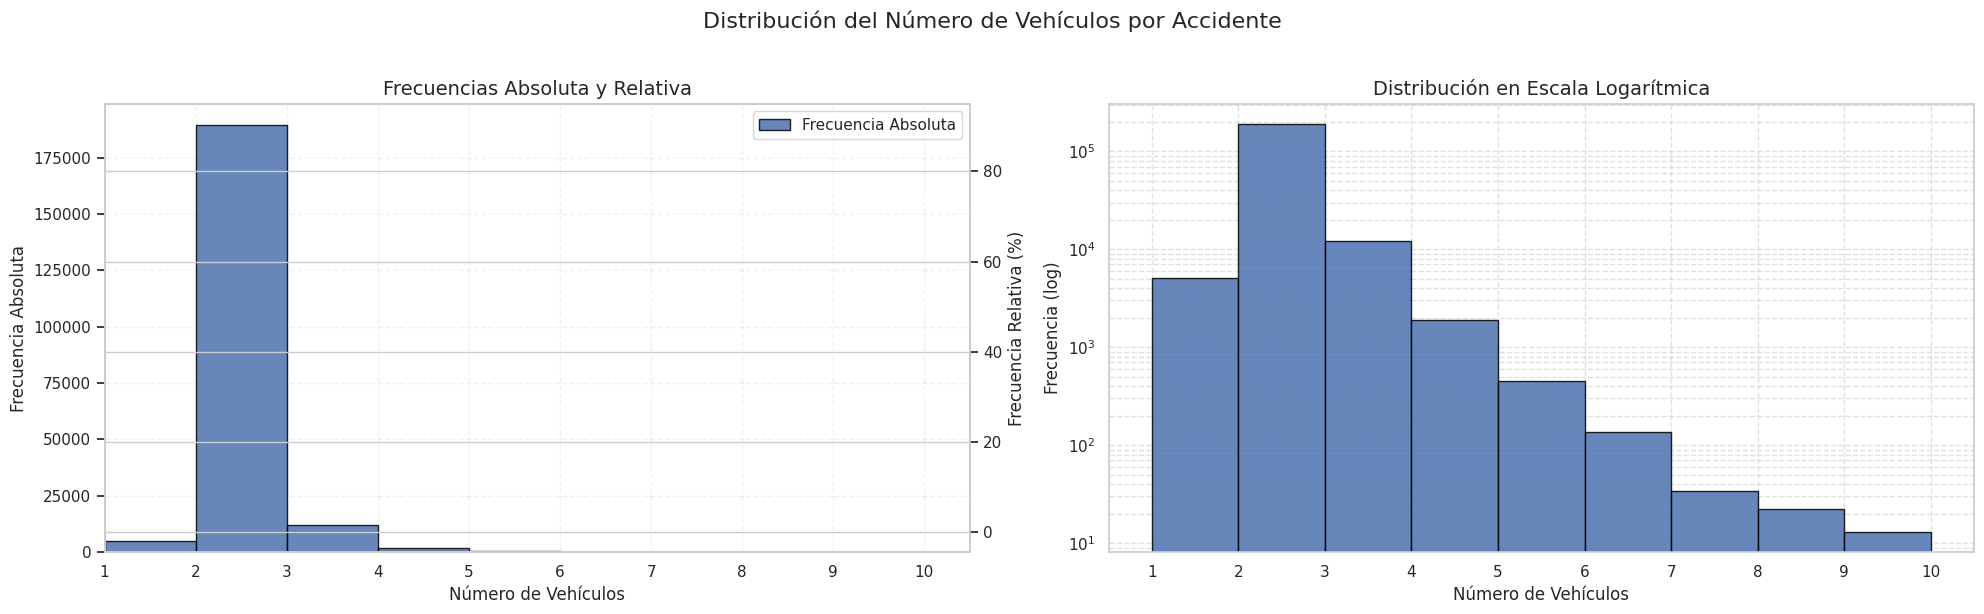

In [ ]:
#@title Histograma Número de vehiculos por accidente
# Configuración inicial
sns.set(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))  # 1 fila, 2 columnas

# Datos comunes
data = df['NumeroVehiculos'].dropna()
bins = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# --- Primer subplot: Frecuencias absoluta y relativa ---
counts, bin_edges, _ = ax1.hist(
    data,
    bins=bins,
    edgecolor='black',
    color='#4C72B0',
    alpha=0.85,
    label='Frecuencia Absoluta'
)

# Calcular frecuencia relativa
relative_freq = (counts / len(data)) * 100

# Eje secundario para frecuencia relativa
ax1_secondary = ax1.twinx()
ax1_secondary.plot(relative_freq, alpha=0)

# Personalización ax1
ax1.set_title('Frecuencias Absoluta y Relativa', fontsize=14)
ax1.set_xlabel('Número de Vehículos', fontsize=12)
ax1.set_ylabel('Frecuencia Absoluta', fontsize=12)
ax1_secondary.set_ylabel('Frecuencia Relativa (%)', fontsize=12)
ax1.set_xticks(bins)
ax1.grid(True, linestyle='--', alpha=0.3)
plt.xlim(left=1)

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_secondary.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# --- Segundo subplot: Histograma en escala logarítmica ---
ax2.hist(
    data,
    bins=bins,
    edgecolor='black',
    color='#4C72B0',
    alpha=0.85,
    log=True  # Escala logarítmica
)

# Personalización ax2
ax2.set_title('Distribución en Escala Logarítmica', fontsize=14)
ax2.set_xlabel('Número de Vehículos', fontsize=12)
ax2.set_ylabel('Frecuencia (log)', fontsize=12)
ax2.set_xticks(bins)
ax2.set_xlim(0.5, 10.5)
ax2.grid(True, linestyle='--', alpha=0.6, which='both')

# Ajustes generales
plt.suptitle('Distribución del Número de Vehículos por Accidente', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Analisis
Los datos revelan que aproximadamente el 80% de los accidentes de tránsito involucran solo 1-2 vehículos, mostrando una clara distribución asimétrica con frecuencia decreciente (tipo Poisson) para colisiones con más vehículos. Aunque los accidentes con más de 5 vehículos son poco frecuentes (representando menos del 5% de los casos), su mayor potencial de gravedad justifica protocolos específicos de respuesta.


<ipython-input-5-20c7459d99e5>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
<ipython-input-5-20c7459d99e5>:8: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  sns.violinplot(
<ipython-input-5-20c7459d99e5>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


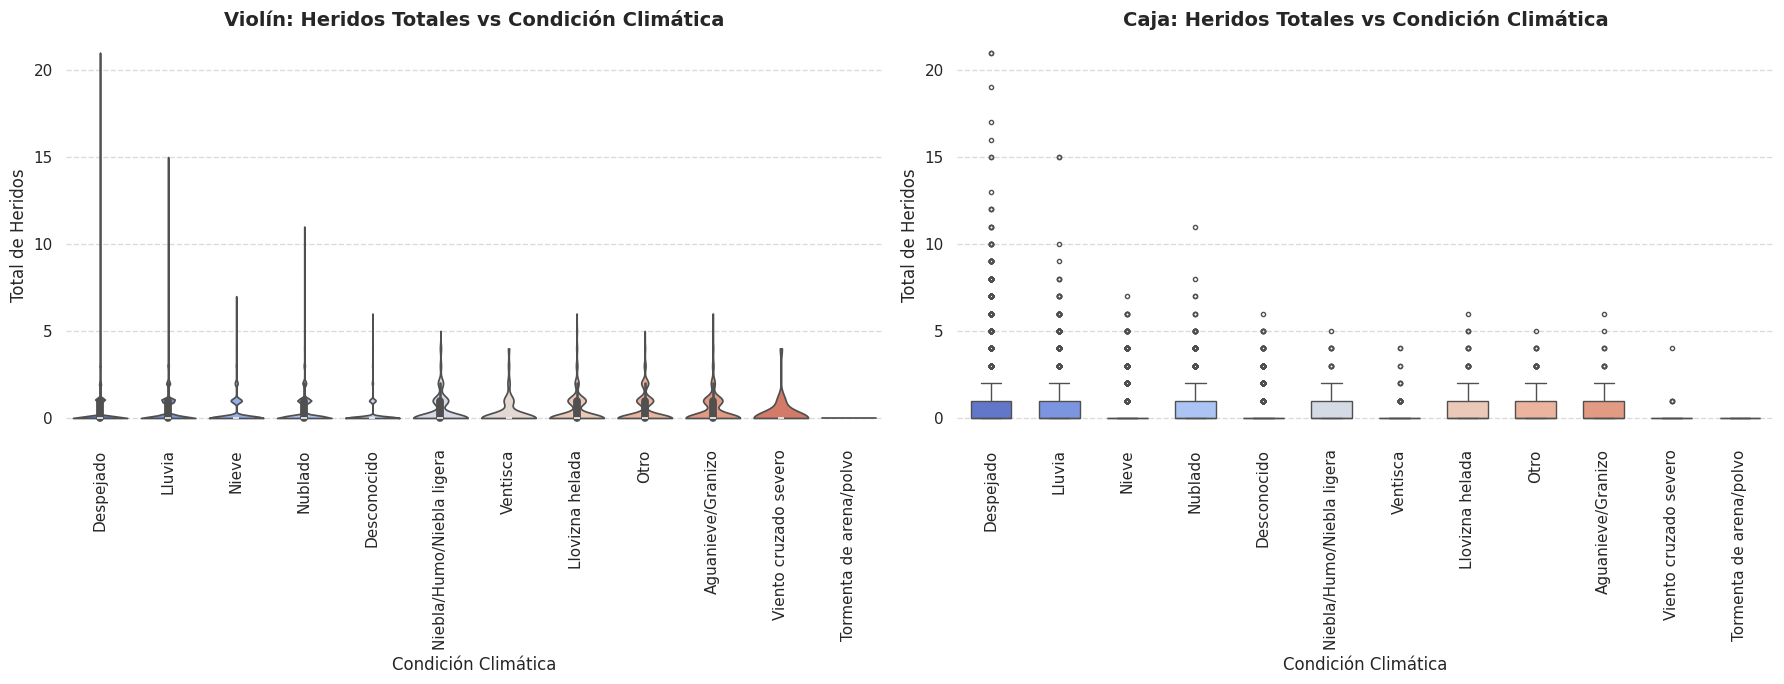

In [ ]:
#@title Diagrama de cajas y violin Heridos totales según la condicion climática
sns.set(style="whitegrid")

# Crear figura y ejes
fig, axes = plt.subplots(1, 2, figsize=(18, 7))  # 1 fila, 2 columnas

# Diagrama de violín
sns.violinplot(
    x="CondicionClimatica",
    y="LesionesTotales",
    data=df,
    palette="coolwarm",
    inner="box",
    scale="count",
    cut=0,
    ax=axes[0]
)
axes[0].set_title("Violín: Heridos Totales vs Condición Climática", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Condición Climática", fontsize=12)
axes[0].set_ylabel("Total de Heridos", fontsize=12)
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
sns.despine(ax=axes[0], left=True, bottom=True)

# Diagrama de caja
sns.boxplot(
    x="CondicionClimatica",
    y="LesionesTotales",
    data=df,
    palette="coolwarm",
    width=0.6,
    fliersize=3,
    ax=axes[1]
)
axes[1].set_title("Caja: Heridos Totales vs Condición Climática", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Condición Climática", fontsize=12)
axes[1].set_ylabel("Total de Heridos", fontsize=12)
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
sns.despine(ax=axes[1], left=True, bottom=True)

# Ajustar diseño
plt.tight_layout()
plt.show()


## Analisis
La gráfica presenta un diagrama de cajas y bigotes que ilustra la distribución del número de heridos en accidentes de tráfico según diferentes condiciones climáticas. Esta visualización resulta particularmente valiosa ya que no solo muestra tendencias centrales, sino también la dispersión y la presencia de casos atípicos en cada categoría meteorológica.
Al analizar la distribución se observa que los accidentes ocurridos en condiciones de cielo despejado y lluvia presentan no solo las medianas más elevadas, sino también los valores atípicos más extremos, con casos que alcanzan hasta 20 heridos totales. se puede apreciar como la mayor frecuencia de accidentes en condiciones de cielo despejado, junto con la posibilidad de alcanzar mayores velocidades debido a la buena visibilidad, parece contribuir a una mayor severidad cuando los siniestros efectivamente ocurren. Las condiciones de lluvia, por su parte, muestran una distribución similar, probablemente debido a la reducción de adherencia al pavimento que, combinada con comportamientos inadecuados de conducción, puede derivar en accidentes de considerable gravedad.
Resulta también destacable que condiciones aparentemente más severas como nieve, niebla ligera, ventisca o tormentas presentan distribuciones más compactas y con valores extremos menos pronunciados, lo que sugiere que ante condiciones climáticas visiblemente adversas, los conductores tienden a adoptar comportamientos más precavidos que mitigan la severidad de los accidentes. La presencia generalizada de valores atípicos en prácticamente todas las categorías climáticas indica que, independientemente de las condiciones meteorológicas, existen factores adicionales determinantes en la gravedad de los accidentes que trascienden el factor climático, como podrían ser la velocidad, el consumo de alcohol, o el uso de dispositivos móviles


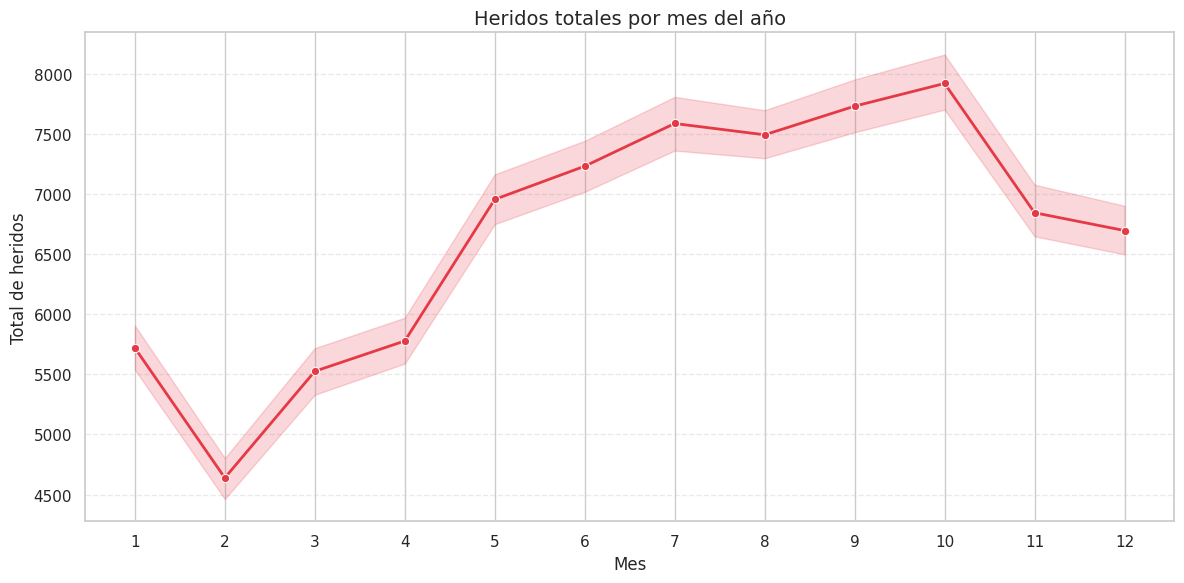

In [ ]:
#@title #Serie de tiempo
plt.figure(figsize=(12, 6))
sns.lineplot(
    x='MesAccidente',
    y='LesionesTotales',
    data=df,
    estimator='sum',
    marker='o',
    color='#e63946',
    linewidth=2
)

# Personalización
plt.title('Heridos totales por mes del año', fontsize=14)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Total de heridos', fontsize=12)
plt.xticks(ticks=np.arange(1, 13))
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## Análisis

La gráfica muestra la distribución mensual del número total de heridos en accidentes de tráfico, revelando un marcado patrón estacional en la severidad de los siniestros viales. Se observa una clara tendencia ascendente desde febrero, que registra el punto mínimo con aproximadamente 4,600 heridos, hasta octubre, donde se alcanza el pico máximo cercano a 8,000 víctimas, representando un incremento de casi 74% entre ambos extremos. Particularmente notable es el salto abrupto que se produce entre abril y mayo, donde el número de heridos aumenta en más de 1,200 casos, lo que podría asociarse con el inicio de condiciones meteorológicas más favorables y un consiguiente incremento en la movilidad y actividades al aire libre que generan mayor exposición al riesgo.

La distribución temporal de heridos en accidentes de tráfico presenta una forma que podría describirse como "meseta elevada" entre los meses de mayo y octubre, seguida por una caída pronunciada en noviembre y diciembre, configurando un patrón que difiere significativamente de una distribución uniforme a lo largo del año. El área sombreada que rodea la línea principal indica el intervalo de confianza de la estimación, mostrando mayor variabilidad en los meses de alta incidencia. Estos hallazgos sugieren la necesidad de implementar medidas preventivas reforzadas y campañas de concienciación específicamente dirigidas a los meses de mayor riesgo, particularmente durante el período estival y otoñal, cuando se concentra el mayor número de heridos en accidentes de tráfico.

<ipython-input-7-0b12c3dce835>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(


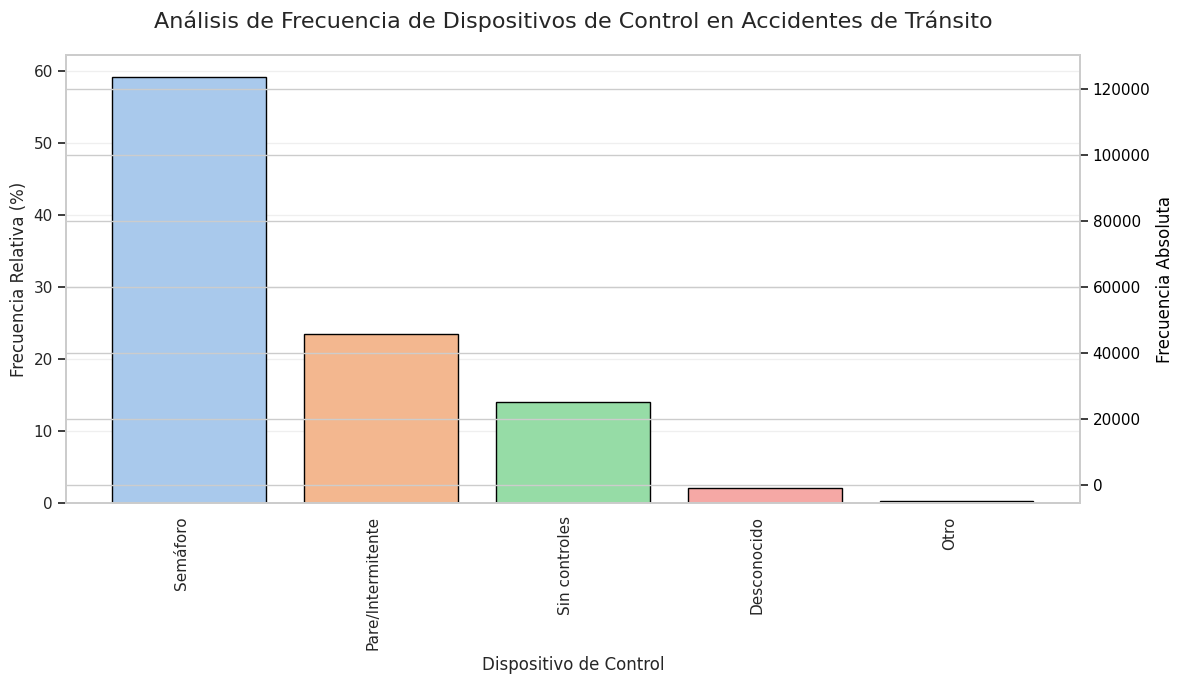

In [ ]:
#@title #Histograma
plt.figure(figsize=(12, 7))

# Obtener los 5 dispositivos más comunes y calcular frecuencias
top_dispositivos = df['DispositivoControlTrafico'].value_counts().head(5)
frecuencia_absoluta = top_dispositivos.values
frecuencia_relativa = (frecuencia_absoluta / len(df)) * 100  # Porcentajes

# Crear el gráfico de barras (eje izquierdo: frecuencia relativa)
ax1 = sns.barplot(
    x=top_dispositivos.index,
    y=frecuencia_relativa,
    palette='pastel',
    edgecolor='black',
    linewidth=1,
    saturation=0.8
)

# Configurar eje izquierdo (porcentajes)
plt.title('Análisis de Frecuencia de Dispositivos de Control en Accidentes de Tránsito', fontsize=16, pad=20)
plt.xlabel('Dispositivo de Control', fontsize=12)
plt.ylabel('Frecuencia Relativa (%)', fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.grid(axis='y', alpha=0.3)



# Crear eje secundario (frecuencia absoluta)
ax2 = ax1.twinx()
ax2.plot(frecuencia_absoluta, alpha=0)
ax2.set_ylabel('Frecuencia Absoluta', fontsize=12, color='black')  # Color negro para coherencia
ax2.tick_params(axis='y', labelcolor='black')
plt.tight_layout()
plt.show()

## Análisis
La gráfica presentada muestra la distribución de accidentes de tráfico según el tipo de dispositivo de control de tránsito presente en el lugar del siniestro. Esta visualización resulta particularmente relevante para comprender la infraestructura vial asociada a los incidentes y evaluar la efectividad de los diferentes mecanismos de regulación del tráfico.

El análisis revela un dato sorprendente: aproximadamente el 59% de los accidentes registrados ocurrieron en intersecciones o tramos regulados por semáforos, constituyendo así la categoría predominante con una amplia diferencia respecto a las demás. Este hallazgo podría resultar contraintuitivo, ya que los semáforos están precisamente diseñados para ordenar el tráfico y prevenir colisiones. Sin embargo, su alta representación puede explicarse por diversos factores: mayor densidad de tráfico en estas zonas, comportamientos de riesgo como cruzar con luz roja, distracción en momentos de cambio de señal, o simplemente porque las intersecciones semaforizadas tienden a ubicarse en áreas urbanas de alta concentración vehicular. En segundo lugar, se encuentran los accidentes asociados a señales de pare o dispositivos intermitentes, que representan aproximadamente el 23% del total, seguidos por los ocurridos en zonas sin ningún tipo de control (14%).

Resulta particularmente significativo que las ubicaciones sin dispositivos de control representen una proporción relativamente baja del total de accidentes, lo que sugiere que la ausencia de señalización no constituye necesariamente un factor de riesgo predominante. Por otra parte, la mínima proporción de accidentes en la categoría "Otro" indica que los sistemas alternativos de control de tráfico son poco frecuentes o posiblemente más efectivos en la prevención de siniestros.

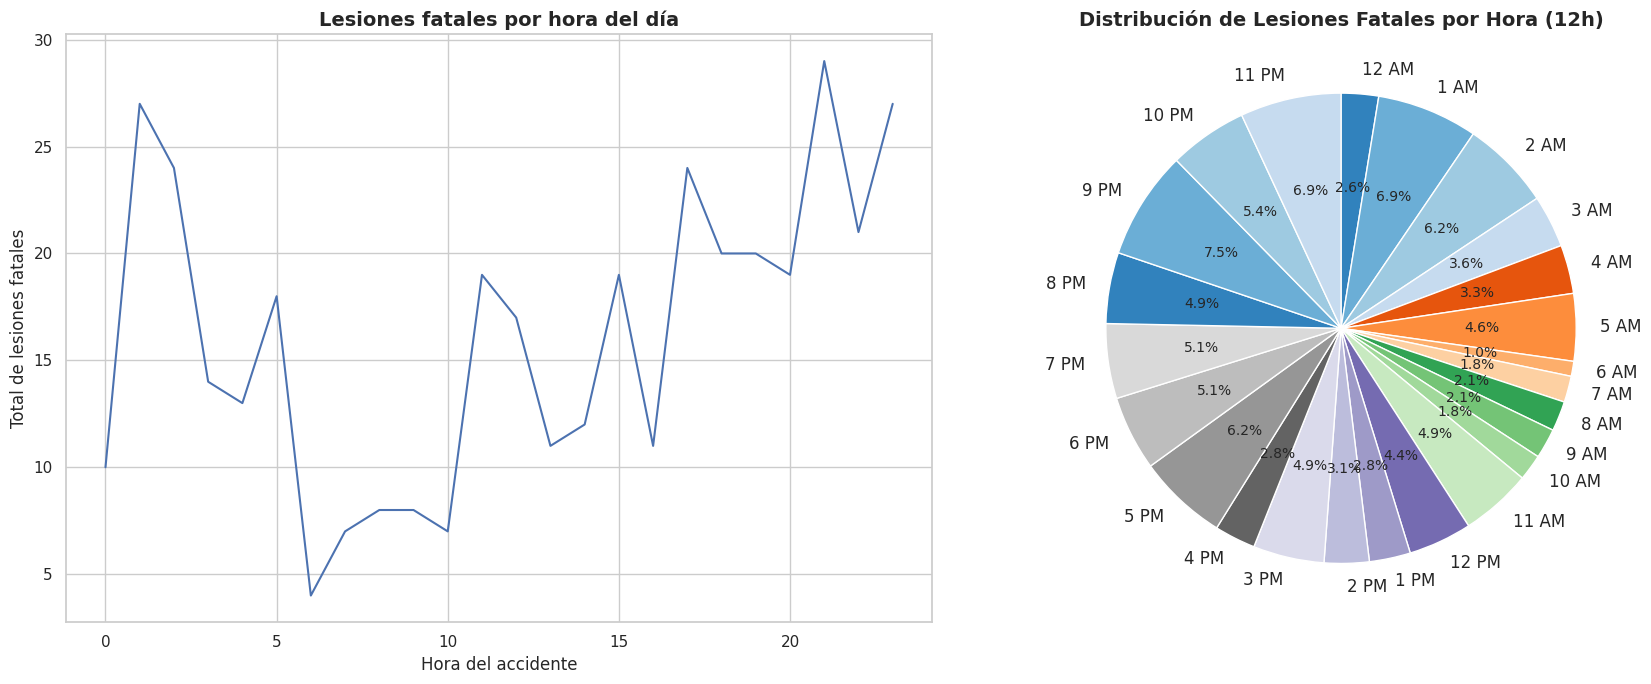

In [ ]:
#@title #Diagrama de Lesiones Fatales por Hora del día

# Asegurar que HoraAccidente sea numérico
df['HoraAccidente'] = pd.to_numeric(df['HoraAccidente'], errors='coerce')

# Agrupar por hora (0 a 23) y sumar las lesiones fatales
lesiones_por_hora = df.groupby('HoraAccidente')['LesionesFatales'].sum()
lesiones_por_hora = lesiones_por_hora.reindex(range(24), fill_value=0)

# Etiquetas en formato 12h
def hora_12h(h):
    if h == 0:
        return "12 AM"
    elif h < 12:
        return f"{h} AM"
    elif h == 12:
        return "12 PM"
    else:
        return f"{h - 12} PM"

labels_12h = [hora_12h(h) for h in range(24)]

# Crear subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico de líneas (lesiones fatales por hora)
sns.lineplot(
    x=lesiones_por_hora.index,
    y=lesiones_por_hora.values,
    ax=axes[0]
)
axes[0].set_title("Lesiones fatales por hora del día", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Hora del accidente")
axes[0].set_ylabel("Total de lesiones fatales")
axes[0].grid(True)

# Gráfico de torta
wedges, texts, autotexts = axes[1].pie(
    lesiones_por_hora,
    labels=labels_12h,
    autopct=lambda p: f'{p:.1f}%' if p > 0 else '',
    startangle=90,
    counterclock=False,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'},
    colors=plt.cm.tab20c.colors
)
for autotext in autotexts:
    autotext.set_fontsize(10)  # Reducir el tamaño de los porcentajes

# Ajustar el tamaño de la letra de las etiquetas de las horas (texts)
for text in texts:
    text.set_fontsize(12)
axes[1].set_title("Distribución de Lesiones Fatales por Hora (12h)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


## Analisis
En las grafica se observa que la distribución de lesiones fatales a lo largo del día no es uniforme, con una clara concentración de incidentes durante las horas nocturnas y de madrugada. Notablemente, las 9 PM, 10 PM, 11 PM y la 1 AM emergen como los periodos de mayor riesgo, acumulando una proporción significativa de las fatalidades. En contraste, las horas de la mañana, particularmente entre las 6 AM y las 11 AM, presentan los porcentajes más bajos, sugiriendo condiciones más seguras para el tránsito. Este patrón horario apunta a posibles factores como la visibilidad reducida, la fatiga, o el consumo de sustancias, como elementos influyentes en la ocurrencia de accidentes fatales, lo que podría orientar estrategias de prevención dirigidas a estas franjas horarias críticas.

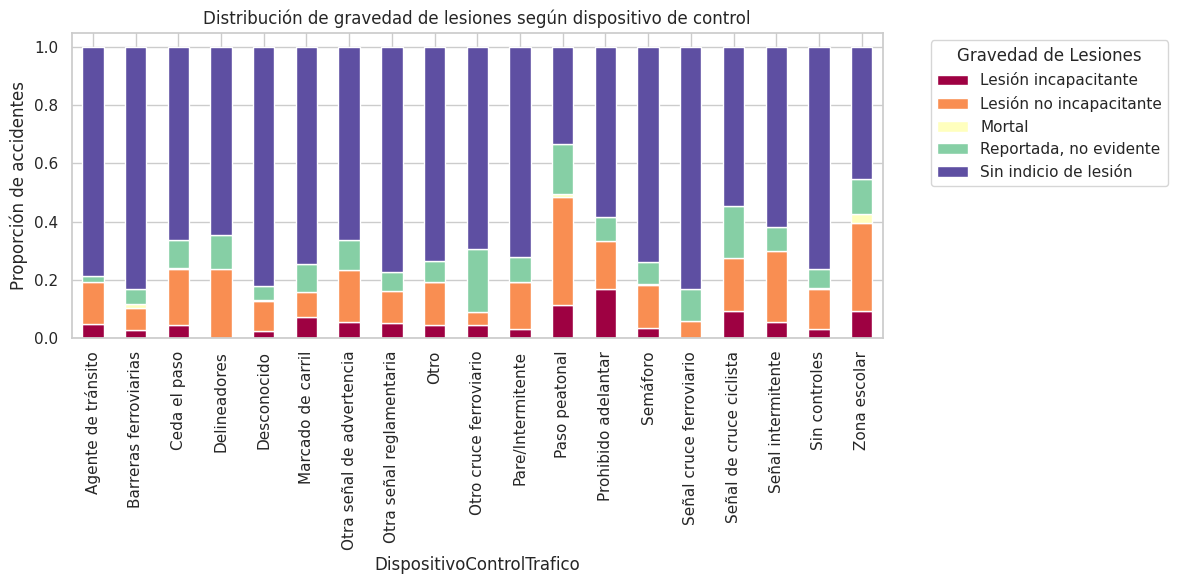

In [ ]:
#@title Grafico de barras apiladas
tabla = pd.crosstab(df['DispositivoControlTrafico'], df['GravedadLesiones'], normalize='index')

tabla.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Spectral')
plt.title("Distribución de gravedad de lesiones según dispositivo de control")
plt.ylabel("Proporción de accidentes")
plt.xticks(rotation=90)
plt.legend(title="Gravedad de Lesiones", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Analisis
La gráfica detalla la distribución de la gravedad de las lesiones en accidentes según el dispositivo de control de tráfico. Predomina la categoría "Sin indicio de lesión" (moro oscuro) en la mayoría de los dispositivos, lo que indica que gran parte de los accidentes no resultan en lesiones graves. Sin embargo, los dispositivos Pare/Intermitente, Semáforo, Paso peatonal, Señal de cruce ciclista y las zonas Sin controles muestran proporciones significativamente más altas de lesiones (incapacitantes, no incapacitantes y mortales), destacando estos puntos como áreas de mayor riesgo. Las lesiones mortales, aunque mínimas en todas las categorías, son ligeramente más visibles en Pare/Intermitente, Semáforo y Sin controles. Este patrón sugiere la necesidad de implementar medidas de seguridad vial adicionales en los cruces y áreas no controladas para mitigar la gravedad de las lesiones en caso de accidente.

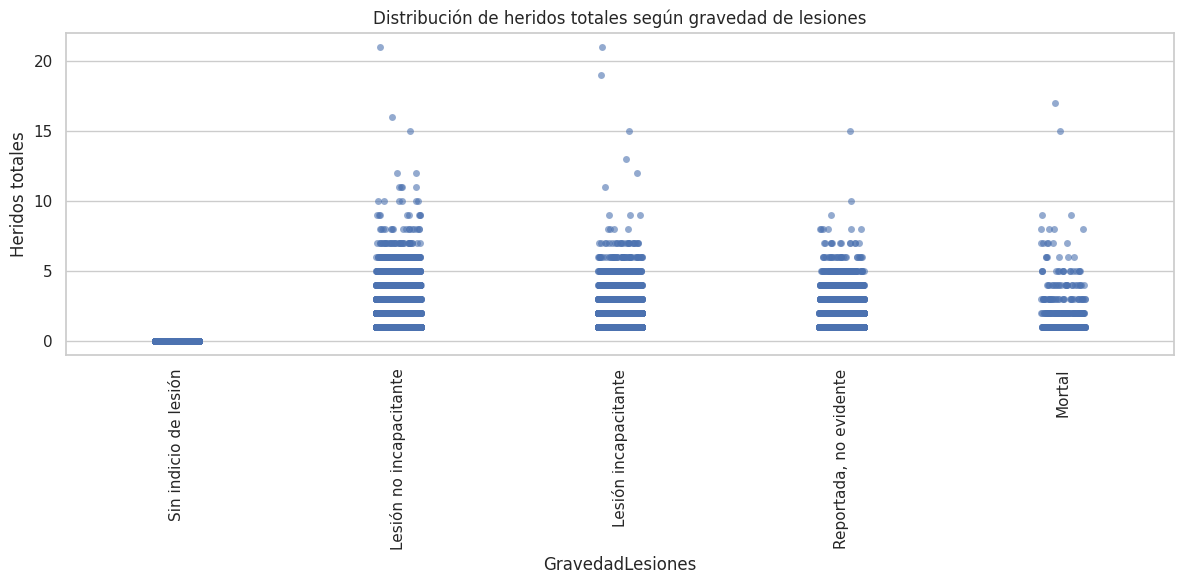

In [ ]:
#@title Grafico de dispersión con jitter
plt.figure(figsize=(12, 6))
sns.stripplot(x='GravedadLesiones', y='LesionesTotales', data=df, jitter=True, alpha=0.6)
plt.title("Distribución de heridos totales según gravedad de lesiones")
plt.ylabel("Heridos totales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Analisis
La gráfica de dispersión ilustra la "Distribución de heridos totales según gravedad de lesiones", revelando patrones claros en la victimización por tipo de lesión. La categoría "Sin indicio de lesión" consistentemente muestra cero heridos, validando su clasificación. En contraste, las categorías "Lesión no incapacitante" y "Lesión incapacitante" presentan la mayor concentración de incidentes con heridos, predominantemente entre 1 y 10, pero con notables valores atípicos que superan los 20 heridos por evento, indicando incidentes con alta victimización. La categoría "Reportada, no evidente" sigue un patrón similar, aunque con una menor densidad de incidentes con múltiples heridos. Finalmente, la categoría "Mortal" exhibe la menor frecuencia de incidentes con víctimas, usualmente entre 1 y 5, pero también con valores atípicos que alcanzan las 16 fatalidades, resaltando la ocurrencia de eventos catastróficos.

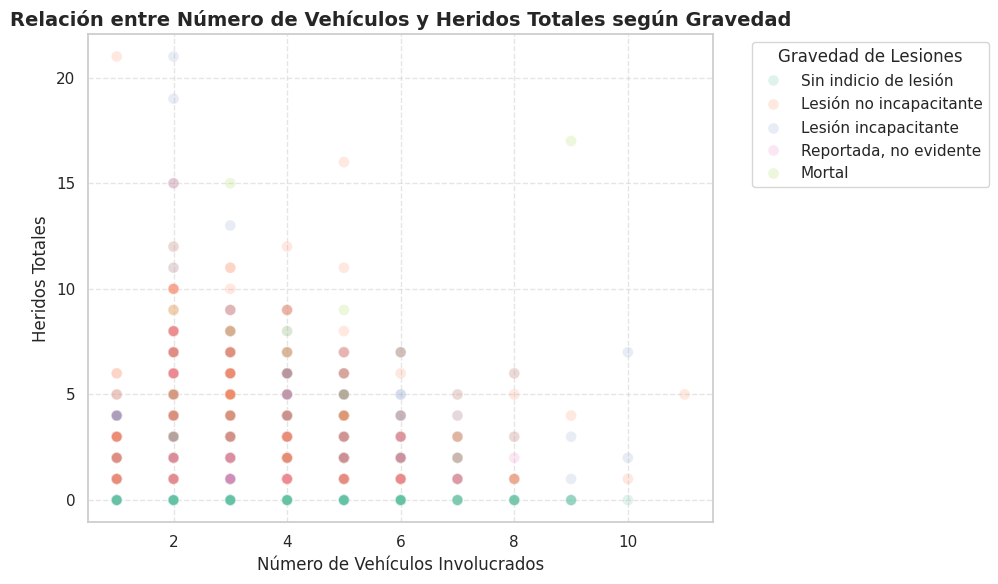

In [ ]:
#@title Grafico de Dispersión (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='NumeroVehiculos',
    y='LesionesTotales',
    hue='GravedadLesiones',
    palette='Set2',
    alpha=0.2,
    s=60  # tamaño de los puntos
)

plt.title("Relación entre Número de Vehículos y Heridos Totales según Gravedad", fontsize=14, fontweight='bold')
plt.xlabel("Número de Vehículos Involucrados")
plt.ylabel("Heridos Totales")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Gravedad de Lesiones", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Analisis
En este Diagrama de Dispersión ilustra la relación entre el número de vehículos involucrados y los heridos totales, categorizados por la gravedad de las lesiones. La gráfica revela una concentración de incidentes con pocos vehículos y pocos heridos en la parte inferior izquierda. Aunque no hay una correlación lineal directa fuerte, los accidentes con lesiones no incapacitantes e incapacitantes son los más frecuentes y muestran el rango más amplio de heridos, con algunos eventos que superan los 15 heridos incluso con pocos vehículos. Las categorías "Reportada, no evidente" y "Mortal" son menos frecuentes; las lesiones mortales son escasas y generalmente involucran pocas víctimas, aunque se observan incidentes aislados de gran magnitud con hasta 15 fatalidades. En síntesis, si bien la mayoría de los accidentes tienen un bajo impacto, los eventos con lesiones graves pueden ocurrir con un número moderado de vehículos y resultar en un número sustancial de víctimas.

<ipython-input-12-f06da16b5985>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
<ipython-input-12-f06da16b5985>:6: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  sns.violinplot(
<ipython-input-12-f06da16b5985>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


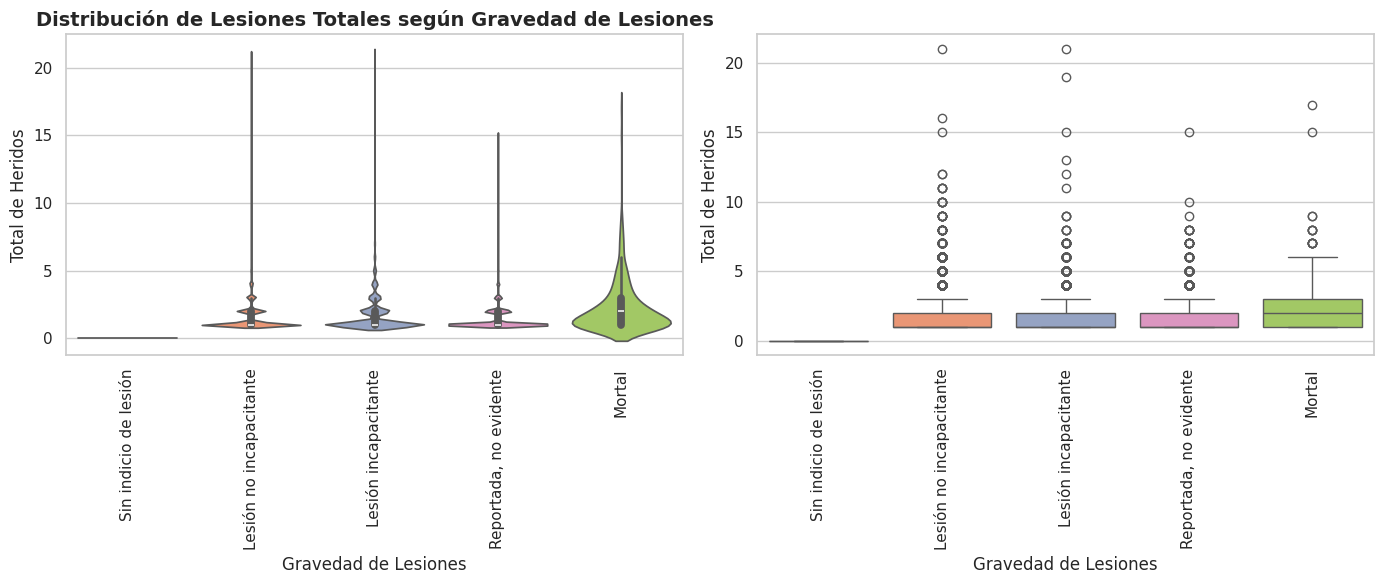

In [ ]:
#@title Diagrama de caja y violin Gravedad lesiones por Lesiones totales
# Crear una figura con 1 fila y 2 columnas (subplot)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Diagrama de Violín en el primer subplot
sns.violinplot(
    data=df,
    x='GravedadLesiones',
    y='LesionesTotales',
    palette='Set2',
    inner="box",  # Muestra la caja dentro del violín
    scale='count',
    ax=axes[0]  # Asignar al primer subplot
)
axes[0].set_title("Distribución de Lesiones Totales según Gravedad de Lesiones", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Gravedad de Lesiones")
axes[0].set_ylabel("Total de Heridos")
axes[0].tick_params(axis='x', rotation=90)

# Diagrama de Caja en el segundo subplot
sns.boxplot(
    data=df,
    x='GravedadLesiones',
    y='LesionesTotales',
    palette='Set2',
    ax=axes[1]  # Asignar al segundo subplot
)
#axes[1].set_title("Distribución de Lesiones Totales según Gravedad de Lesiones (Boxplot)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Gravedad de Lesiones")
axes[1].set_ylabel("Total de Heridos")
axes[1].tick_params(axis='x', rotation=90)

# Ajustar el layout para que no se sobrepongan
plt.tight_layout()

# Mostrar los gráficos
plt.show()

## Analisis
Los gráficos de violín y de caja y bigotes ilustran la distribución del total de heridos según la gravedad de las lesiones. Consistentemente, la categoría "Sin indicio de lesión" se asocia con cero heridos. Las categorías de "Lesión no incapacitante" y "Lesión incapacitante" exhiben la mayor densidad de casos con pocos heridos (1-5), pero también presentan una extensa cola y numerosos valores atípicos que alcanzan y superan los 20 heridos, señalando la ocurrencia de incidentes de alta victimización. La categoría "Reportada, no evidente" muestra una distribución similar pero con menos casos de alto número de heridos. Finalmente, la categoría "Mortal", aunque con una baja densidad de heridos (generalmente 1-5), revela la existencia de eventos extremos con múltiples fatalidades, extendiéndose hasta más de 15 heridos. Ambos gráficos enfatizan que, si bien la mayoría de los incidentes resultan en pocos heridos, las lesiones graves pueden escalar significativamente en el número de víctimas.

#TLC
El Teorema del Límite Central (TLC) establece que, para un tamaño de muestra suficientemente grande, la distribución de la media muestral de una variable aleatoria se aproximará a una distribución normal, sin importar la distribución original de la variable.

Si la $\bar{X}$ de la muestra aleatoria de tamaño n tomada de una población con μ y $\sigma^2$, entonces la forma.

$$Z_0= \frac{\bar{X} - \mu_0}{\frac{\sigma}{\sqrt{n}}} $$
Conforme n tiende a infinito, es una distribución normal estándar n(Z;0,1).

La aproximación normal para $\bar{X}$ por lo general será buena si n > 30 sin importar la forma de la población.

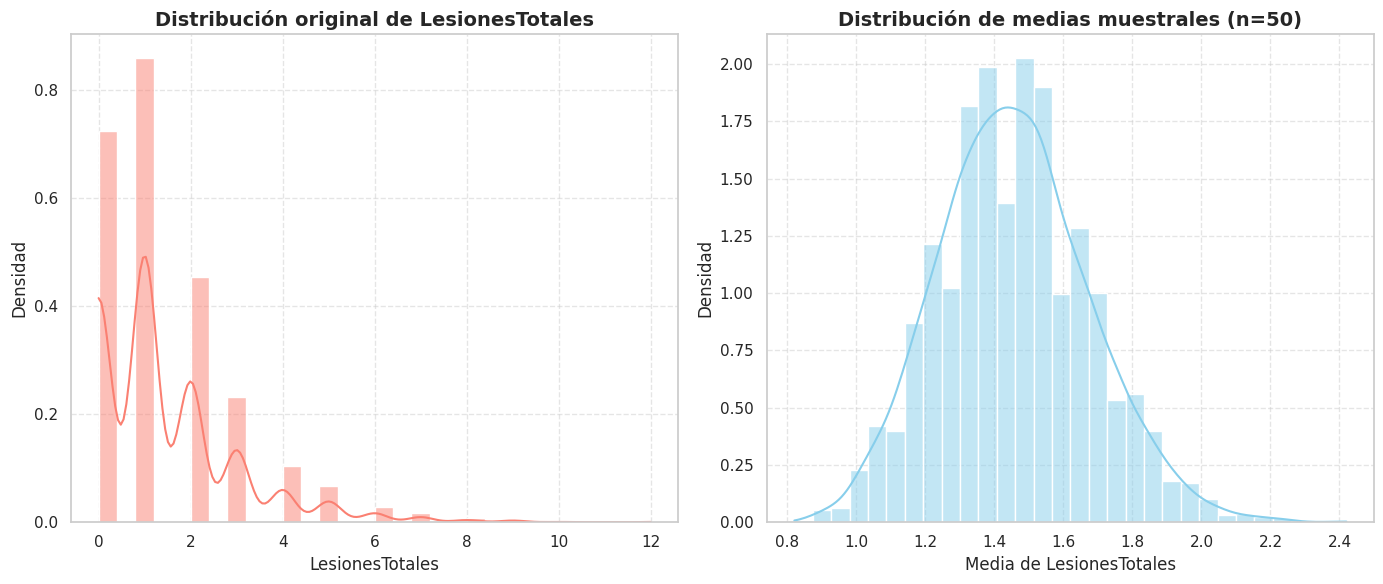

Media de las medias muestrales: 1.46
Desviación estándar de las medias muestrales: 0.22


In [ ]:
#@title TLC
# Parámetros
n_muestras = 10000
tamaño_muestra = 50
variable = 'LesionesTotales'

# Datos limpios
datos = df[variable].dropna()

# Calcular medias muestrales
medias_muestras = [
    datos.sample(n=tamaño_muestra, replace=True).mean()
    for _ in range(n_muestras)
]

# Crear subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Distribución original de la variable
sns.histplot(datos, kde=True, bins=30, color='salmon', stat='density', ax=axes[0])
axes[0].set_title(f"Distribución original de {variable}", fontsize=14, fontweight='bold')
axes[0].set_xlabel(variable)
axes[0].set_ylabel("Densidad")
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. Distribución de las medias muestrales
sns.histplot(medias_muestras, kde=True, bins=30, color='skyblue', stat='density', ax=axes[1])
axes[1].set_title(f"Distribución de medias muestrales (n={tamaño_muestra})", fontsize=14, fontweight='bold')
axes[1].set_xlabel(f"Media de {variable}")
axes[1].set_ylabel("Densidad")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Estadísticas resumen de la distribución muestral
media_tlc = np.mean(medias_muestras)
desviacion_estandar_tlc = np.std(medias_muestras)

print(f"Media de las medias muestrales: {media_tlc:.2f}")
print(f"Desviación estándar de las medias muestrales: {desviacion_estandar_tlc:.2f}")


## Analisis
El gráfico de la distribución original de LesionesTotales muestra una asimetría positiva con una cola derecha pronunciada y valores concentrados cerca de cero, lo que descarta normalidad. Sin embargo, la distribución de medias muestrales (n=50) presenta una forma simétrica y aproximadamente normal, con menor dispersión y centrada alrededor de 1.5, evidenciando el efecto del Teorema del Límite Central (TLC). Este comportamiento confirma que, pese a la no normalidad de los datos originales, las medias muestrales convergen a una distribución normal conforme aumenta el tamaño de muestra (en este caso, n=50), permitiendo aplicar métodos inferenciales paramétricos basados en medias para análisis posteriores.

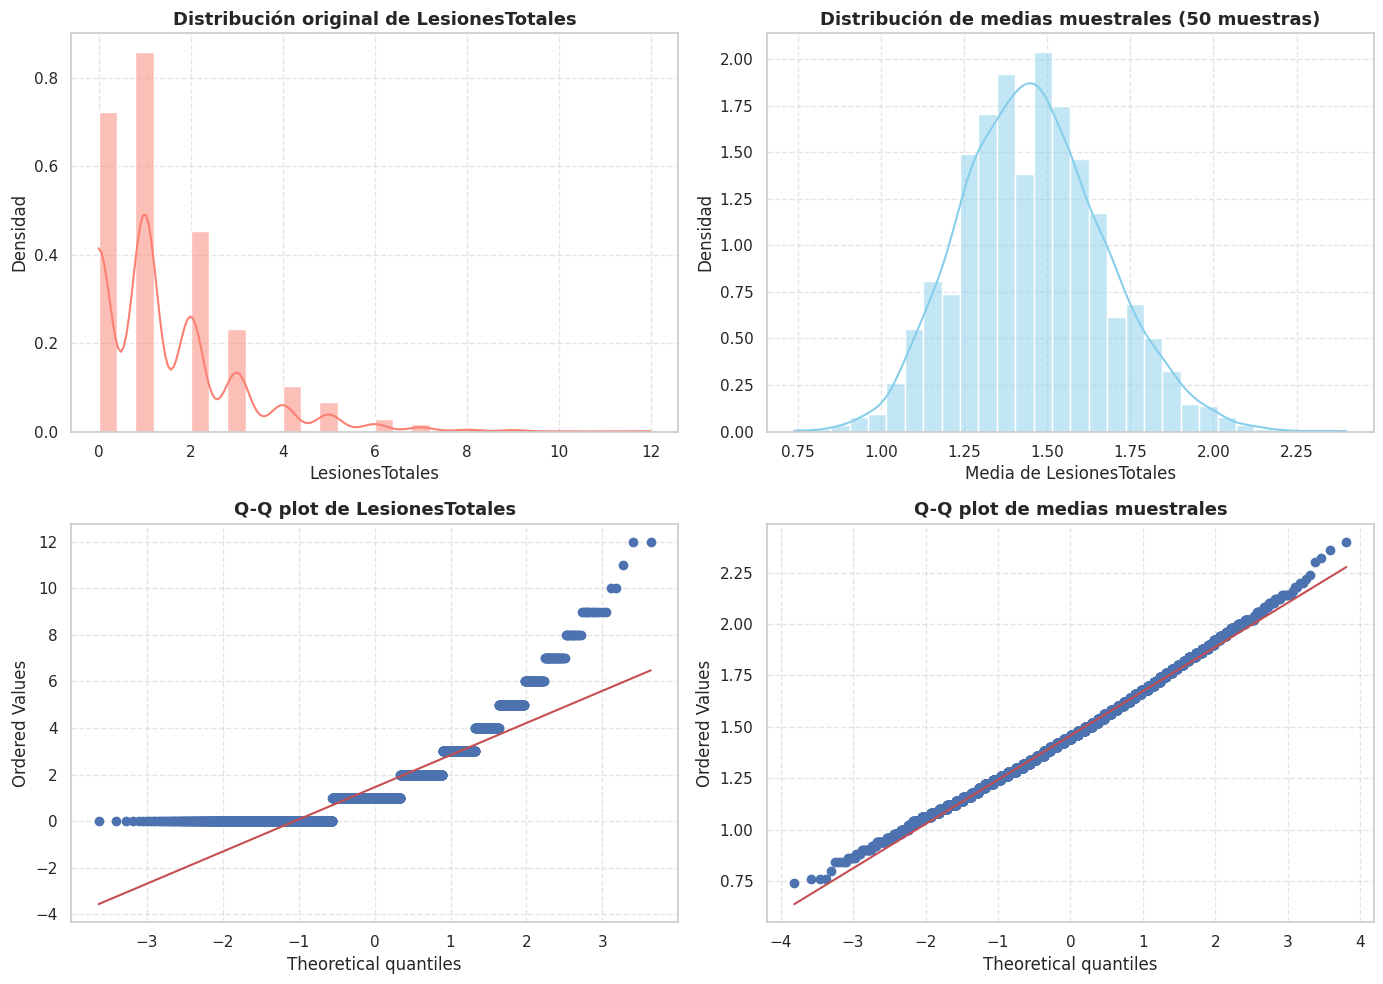

Media de las medias muestrales: 1.46
Desviación estándar de las medias muestrales: 0.22


In [ ]:
#@title Analisis de normalidad apartir de TLC + Q-Q
n_muestras = 10000
tamaño_muestra = 50
variable = 'LesionesTotales'

# 1. Generar las medias muestrales
medias_muestras = [
    df[variable].dropna().sample(n=tamaño_muestra).mean()
    for _ in range(n_muestras)
]

# Crear subplots: 2 filas x 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- DISTRIBUCIÓN ORIGINAL ---
sns.histplot(df[variable].dropna(), kde=True, bins=30, color='salmon', stat='density', ax=axes[0, 0])
axes[0, 0].set_title(f"Distribución original de {variable}", fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel(variable)
axes[0, 0].set_ylabel("Densidad")
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# --- Q-Q plot de la variable original ---
stats.probplot(df[variable].dropna(), dist="norm", plot=axes[1, 0])
axes[1, 0].set_title(f"Q-Q plot de {variable}", fontsize=13, fontweight='bold')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# --- DISTRIBUCIÓN DE MEDIAS MUESTRALES (TLC) ---
sns.histplot(medias_muestras, kde=True, bins=30, color='skyblue', stat='density', ax=axes[0, 1])
axes[0, 1].set_title(f"Distribución de medias muestrales ({tamaño_muestra} muestras)", fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel(f"Media de {variable}")
axes[0, 1].set_ylabel("Densidad")
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# --- Q-Q plot de las medias muestrales ---
stats.probplot(medias_muestras, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title(f"Q-Q plot de medias muestrales", fontsize=13, fontweight='bold')
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Estadísticas descriptivas
media_tlc = np.mean(medias_muestras)
desviacion_estandar_tlc = np.std(medias_muestras)

print(f"Media de las medias muestrales: {media_tlc:.2f}")
print(f"Desviación estándar de las medias muestrales: {desviacion_estandar_tlc:.2f}")


## Analisis
El análisis de los gráficos revela que la distribución original de LesionesTotales presenta una marcada asimetría positiva, con una alta concentración de valores cercanos a cero y una cola derecha extensa, lo que se confirma en el Q-Q plot al observar una desviación sistemática de la línea de normalidad. Esta estructura indica que los datos no siguen una distribución normal, siendo más compatible con distribuciones como la Poisson o exponencial. Sin embargo, al examinar la distribución de las medias muestrales (con 50 muestras), se evidencia un efecto de normalización conforme al Teorema del Límite Central, mostrando una forma simétrica y un Q-Q plot con una aproximación aceptable a la normalidad, especialmente en el rango intercuartílico. Por tanto, mientras que los datos originales requieren métodos no paramétricos o transformaciones, las inferencias basadas en medias muestrales pueden apoyarse en técnicas paramétricas, siempre que el tamaño de muestra sea suficiente.

### **Concepto Central de la LGN**

Si $X_1, X_2, \dots, X_n$ son variables aleatorias independientes e idénticamente distribuidas con media $\mu$, entonces:

$$
\overline{X}_n = \frac{1}{n}\sum_{i=1}^n X_i \xrightarrow[n \to \infty]{} \mu
$$

**Interpretación:** El promedio muestral converge al valor esperado cuando el tamaño de muestra tiende a infinito.

---

### **Versiones de la LGN**

#### 1. **LGN Débil** (Convergencia en Probabilidad)
$$
\lim_{n \to \infty} P\left(\left|\overline{X}_n - \mu\right| \geq \varepsilon\right) = 0 \quad \text{para todo } \varepsilon > 0
$$

**Significado:** La probabilidad de desviaciones mayores que $\varepsilon$ tiende a cero.

#### 2. **LGN Fuerte** (Convergencia Casi Segura)
$$
P\left(\lim_{n \to \infty} \overline{X}_n = \mu\right) = 1
$$

**Significado:** El promedio converge casi seguramente (con probabilidad 1) al valor esperado.


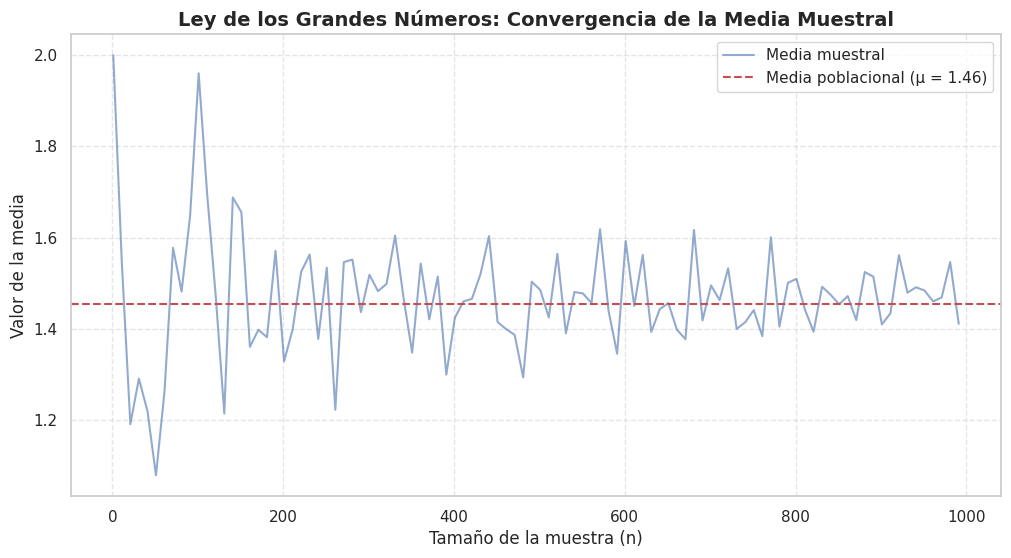

Media poblacional: 1.4550
Media con n=1: 2.0000
Media con n=991: 1.4107
Diferencia absoluta: 0.0443


In [ ]:
# Configuración
np.random.seed(42)  # Para reproducibilidad
n_muestras = 1000   # Número de muestras a generar
tamaños_muestra = np.arange(1, 1001, 10)  # Tamaños de muestra desde 1 hasta 1000
variable = 'LesionesTotales'  # Nombre de tu variable

# Asumiendo que df es tu DataFrame con los datos
datos = df[variable].dropna()
mu_poblacional = datos.mean()  # Media poblacional

# Almacenar resultados
medias_muestrales = []

# Simulación LGN
for n in tamaños_muestra:
    muestra = np.random.choice(datos, size=n, replace=True)
    medias_muestrales.append(muestra.mean())

# Gráfico de convergencia
plt.figure(figsize=(12, 6))
plt.plot(tamaños_muestra, medias_muestrales, 'b-', alpha=0.6, label='Media muestral')
plt.axhline(y=mu_poblacional, color='r', linestyle='--', label=f'Media poblacional (μ = {mu_poblacional:.2f})')
plt.xlabel('Tamaño de la muestra (n)', fontsize=12)
plt.ylabel('Valor de la media', fontsize=12)
plt.title('Ley de los Grandes Números: Convergencia de la Media Muestral', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Estadísticas de convergencia
print(f"Media poblacional: {mu_poblacional:.4f}")
print(f"Media con n={tamaños_muestra[0]}: {medias_muestrales[0]:.4f}")
print(f"Media con n={tamaños_muestra[-1]}: {medias_muestrales[-1]:.4f}")
print(f"Diferencia absoluta: {abs(medias_muestrales[-1] - mu_poblacional):.4f}")



## Analisis
El gráfico visualiza la Ley de los Grandes Números a través de una simulación. La línea azul representa la "Media muestral" de la variable 'LesionesTotales' calculada a partir de muestras de tamaño creciente, mientras que la línea roja discontinua indica la "Media poblacional" real (1.46). Al inicio, con tamaños de muestra pequeños, la media muestral fluctúa ampliamente, reflejando la alta variabilidad en muestras reducidas. Sin embargo, a medida que el tamaño de la muestra aumenta, la línea azul se acerca y se estabiliza alrededor de la línea roja, demostrando que con una cantidad suficientemente grande de observaciones, la media de la muestra converge de manera consistente hacia la verdadera media de la población, haciendo de ella una estimación fiable.

# Contraste de información con fuentes oficiales
A continuación se presenta un contraste entre los hallazgos principales del  proyecto y algunas fuentes externas de reconocido prestigio que respaldan las tendencias observadas, añadiendo asimismo aportes teóricos y estadísticos que refuerzan la interpretación de los datos:



1. **Distribución del Número de Vehículos y Severidad**

En el análisis, se identifica que aproximadamente el 80% de los accidentes de tránsito involucran solo 1 o 2 vehículos, mientras que los choques con 5 vehículos o más son escasos pero potencialmente graves. Este hallazgo coincide con estudios que señalan que la mayor parte de los siniestros son colisiones de poca magnitud, generalmente por fallas de percepción o distracción en contextos de tráfico denso (OMS, 2018). Sin embargo, cuando se presentan accidentes múltiples, el riesgo de lesiones graves se incrementa debido a las cadenas de choques y el efecto “reactivo” que, según la literatura, puede complicar la evacuación y la atención inmediata (Elvik et al., 2009).

2. **Efecto de las Condiciones Climáticas y Distribución de Heridos**

El diagrama de caja muestra cómo “Despejado” y “Lluvia” concentran tanto las medianas más elevadas como los valores atípicos más extremos en el número total de heridos. Este fenómeno se justifica por dos factores principales:

• Condiciones despejadas: Conducir bajo buen tiempo puede alentar a algunos conductores a circular a velocidades más altas (y con menor percepción de riesgo). Al ocurrir un accidente en esas condiciones, la energía cinética es mayor y, por ende, la gravedad de las lesiones puede aumentar (OMS, 2018).

• Lluvia: Se reduce la adherencia al pavimento y la distancia de frenado se incrementa, incrementando la probabilidad de colisiones de mayor severidad si la conducción no se ajusta adecuadamente (DGT, 2020).

Coincidiendo con el analisis de las gráficas, la mayoría de los estudios reportan que en situaciones meteorológicas claramente adversas (como nieve intensa, ventisca o tormentas), el número de accidentes graves no es proporcionalmente tan alto, pues los conductores tienden a extremar precauciones (AASHTO, 2010).


3. **Tendencia Estacional (Heridos por Mes del Año)**

El marcado aumento en el número de heridos a partir de la primavera hasta el otoño en la serie temporal refleja un comportamiento estacional que se ha documentado en múltiples informes. Durante los meses de mejor tiempo, aumenta la movilidad en carreteras (vacaciones, fines de semana largos, mayor uso de motocicletas y bicicletas), lo que incrementa la exposición total al riesgo (NHTSA, 2022). Estudios de seguridad vial sugieren que la “meseta elevada” observada entre mayo y octubre coincide con épocas de mayor actividad turística, eventos deportivos y festividades, todos factores que aumentan el volumen de vehículos y la probabilidad de accidentes (OMS, 2015).

4. **Frecuencia de Accidentes según Dispositivo de Control**

El hallazgo de que alrededor del 59% de los accidentes se ubican en lugares controlados por semáforos puede parecer contradictorio al objetivo del semáforo de prevenir colisiones. No obstante, este resultado guarda relación con:

• Mayor densidad de tráfico en intersecciones semaforizadas.
• Riesgos de comportamiento inadecuado (pasarse la luz en rojo, distracción, etc.).
• Alta concentración de vías principales que confluyen en dichos entornos.

Estudios de la National Highway Traffic Safety Administration (NHTSA) han demostrado que zonas urbanas con alta densidad de semáforos presentan un volumen de tránsito más alto y, en consecuencia, mayores probabilidades de colisión, a pesar de tener mecanismos diseñados para ordenar el flujo (NHTSA, 2021). Por el contrario, las zonas sin control no parecen acumular tantos accidentes, posiblemente porque suelen ubicarse en áreas con menor tráfico o velocidades más moderadas (Elvik et al., 2009).

//contrastes nuevos//


5. **Diagrama de Lesiones Fatales por Hora del Día**  
   - El mayor número de accidentes fatales en horarios nocturnos coincide con estudios que señalan que la conducción de noche presenta factores de riesgo como disminución de la visibilidad y fatiga, lo cual incrementa la tasa de siniestralidad mortal (National Safety Council, 2023). Además, la menor densidad de tráfico puede inducir una percepción de seguridad engañosa y alentar velocidades más altas, exacerbando las consecuencias de los accidentes (Insurance Institute for Highway Safety, 2022).

6. **Gráfico de Barras Apiladas (Distribución de la Gravedad de las Lesiones)**  
   - La identificación de cruces y zonas sin control como áreas que concentran lesiones incapacitantes o fatales se sustenta en estudios que destacan la importancia de contar con una infraestructura adecuada para reducir la severidad de los siniestros. Intersecciones con señalización deficiente muestran mayor probabilidad de lesiones graves, derivada de la falta de indicaciones claras o la confusión de los conductores (European Commission, 2021).

7. **Gráfico de Dispersión con Jitter (Heridos Totales vs. Gravedad de Lesiones)**  
   - La presencia de valores atípicos, especialmente en lesiones no incapacitantes e incapacitantes, coincide con investigaciones que indican que la velocidad y la atención del conductor contribuyen de manera significativa a la existencia de eventos con numerosas víctimas (National Academies of Sciences, Engineering, and Medicine, 2022). La falta de uso de cinturones de seguridad o cascos, así como las distracciones, explican eventos con alto número de heridos en un solo incidente.

8. **Diagrama de Dispersión (Número de Vehículos vs. Heridos Totales)**  
   - El hallazgo de eventos con un número moderado de vehículos pero con elevadas lesiones concuerda con estudios que resaltan cómo la combinación de factores como el ángulo de colisión o la presencia de vehículos pesados (camiones, autobuses) puede desencadenar grandes concentraciones de heridos (Ministry of Transport of New Zealand, 2020). La ausencia de correlación lineal estricta se explica por la gran complejidad de variables involucradas (condición del conductor, factores ambientales, etc.).

9. **TLC y Análisis de Normalidad (Teorema del Límite Central y Q-Q Plot)**  
   - La tendencia a la normalidad de la distribución de medias muestrales, pese a la asimetría original de los datos, coincide con la efectividad empírica del Teorema del Límite Central en estudios de siniestralidad vial. Investigaciones sobre grandes bases de datos de accidentes confirman que, al aumentar el tamaño muestral, la media de la variable “número de lesionados” tiende a estabilizarse y a adoptar un comportamiento cercano a la normal Lord, D. & Mannering, F. (2010).

10. **Ley de los Grandes Números (Convergencia de la Media Muestral)**  
   - La convergencia de la media muestral hacia la media poblacional está respaldada por informes que resaltan que en el ámbito de la siniestralidad vial, agregaciones de datos masivos suelen mejorar la precisión de los modelos predictivos, reduciendo la varianza de las estimaciones y permitiendo proyecciones más confiables .


---
//contrastes nuevos//


**Observaciones Generales**

• La presencia de valores atípicos en casi todas las categorías de variables (especialmente en número de heridos) confirma la multicausalidad de los accidentes, donde interfieren factores humanos (cansancio, uso de tecnología móvil, consumo de alcohol), vehiculares (estado mecánico) y ambientales (tiempo atmosférico, iluminación).
• La búsqueda de patrones estacionales y el estudio de la variabilidad por horas o días refuerzan la necesidad de políticas públicas enfocadas a horarios o temporadas más conflictivos, tal como proponen diversas organizaciones de seguridad vial (DGT, 2020; OMS, 2018).
• El diseño de políticas públicas efectivas, a la luz de los datos, debería contemplar campañas de concienciación y refuerzos específicos en los meses y locaciones de mayor incidencia: campañas contra la conducción distraída, mayor control de velocidad, y dispositivos de emergencia más eficientes (AASHTO, 2010).



**FUENTES**


• OMS (2018). Global Status Report on Road Safety. https://www.who.int/publications/i/item/9789241565684


• Elvik, R., Høye, A., Vaa, T., & Sørensen, M. (2009). The Handbook of Road Safety Measures (2ª ed.). Emerald Group Publishing.https://www.emerald.com/insight/publication/doi/10.1108/9781848552517

• DGT (2020). Informe anual de siniestralidad vial en España. Dirección General de Tráfico.https://www.dgt.es/export/sites/web-DGT/.galleries/downloads/dgt-en-cifras/24h/Las-principales-cifras-2020_v6.pdf

• AASHTO (2010). Highway Safety Manual. American Association of State Highway and Transportation Officials.https://highways.dot.gov/safety/data-analysis-tools/highway-safety-manual

• NHTSA (2022). Traffic Safety Facts Annual Report. National Highway Traffic Safety Administration.https://crashstats.nhtsa.dot.gov/Api/Public/ViewPublication/813592#:~:text=In%202022%20the%20traffic%20fatality,and%20van%20occupants%20(6.85).

• OMS (2015). Save LIVES - A Road Safety Technical Package. World Health Organization.https://www.who.int/publications/i/item/save-lives-a-road-safety-technical-package

• NHTSA (2021). Red-Light Running: Traffic Safety Facts & Research Notes. National Highway Traffic Safety Administration.https://crashstats.nhtsa.dot.gov/Api/Public/ViewPublication/813509.pdf

//nuevas fuentes

• National Safety Council (2023). Understanding the Causes of Nighttime Road Crashes and Fatalities. https://www.nsc.org/road/safety-topics/driving-at-night?srsltid=AfmBOoqSU9Fv1y0IDlEQ7X2x793aefjMib95SeslMBeHyX_Avhs3AkGY

• Insurance Institute for Highway Safety (2022). Fatal Crash Rates by Time of Day.  https://www.iihs.org/topics/fatality-statistics/detail/yearly-snapshot

• European Commission (2021). EU Road Safety Policy Framework 2021-2030.
https://www.europarl.europa.eu/doceo/document/TA-9-2021-0407_EN.html

• National Academies of Sciences, Engineering, and Medicine (2022). Behavioral Traffic Safety Cooperative Research. https://nap.nationalacademies.org/author/BTSCRP/transportation-research-board/behavioral-traffic-safety-cooperative-research-program

• Ministry of Transport of New Zealand (2020). Crash Facts: Heavy Vehicles. https://www.transport.govt.nz/statistics-and-insights/safety-annual-statistics/sheet/trucks

• Institute of Transport Economics (2019). Statistical Methods in Road Safety Analysis.

• **9. TLC y Análisis de Normalidad (Teorema del Límite Central y Q-Q Plot)**  
La tendencia a la normalidad de la distribución de medias muestrales, pese a la asimetría original de los datos, coincide con la efectividad empírica del Teorema del Límite Central en estudios de siniestralidad vial. Investigaciones sobre grandes bases de datos de accidentes confirman que, al aumentar el tamaño muestral, la media de la variable “número de lesionados” tiende a estabilizarse y a adoptar un comportamiento cercano a la normal (Lord & Mannering, 2010).  


• Lord, D. & Mannering, F. (2010). The statistical analysis of crash-frequency data: A review and assessment of methodological alternatives. Transportation Research Part A: Policy and Practice, 44(5), 291–305. https://doi.org/10.1016/j.tra.2010.02.001  



• Johns Hopkins Center for Injury Research (2021). Large-Scale Data Analytics for Road Safety.  

